In [1]:
# Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the data
df = pd.read_csv('../data/life_expectancy_data_cleaned.csv')

# The first few rows
df.head()

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,polio,total_expenditure,diphtheria,hiv/aids,gdp,population,thinness__1-19_years,thinness_5-9_years,income_composition_of_resources,schooling
0,Afghanistan,2000,0,54.8,321.0,88,0.01,10.424960,62.0,6532,...,24.0,8.20,24.0,0.1,114.560000,293756.0,2.3,2.5,0.338,5.5
1,Afghanistan,2001,0,55.3,316.0,88,0.01,10.574728,63.0,8762,...,35.0,7.80,33.0,0.1,117.496980,2966463.0,2.1,2.4,0.340,5.9
2,Afghanistan,2002,0,56.2,3.0,88,0.01,16.887351,64.0,2486,...,36.0,7.76,36.0,0.1,187.845950,21979923.0,19.9,2.2,0.341,6.2
3,Afghanistan,2003,0,56.7,295.0,87,0.01,11.089053,65.0,798,...,41.0,8.82,41.0,0.1,198.728544,2364851.0,19.7,19.9,0.373,6.5
4,Afghanistan,2004,0,57.0,293.0,87,0.02,15.296066,67.0,466,...,5.0,8.79,5.0,0.1,219.141353,24118979.0,19.5,19.7,0.381,6.8


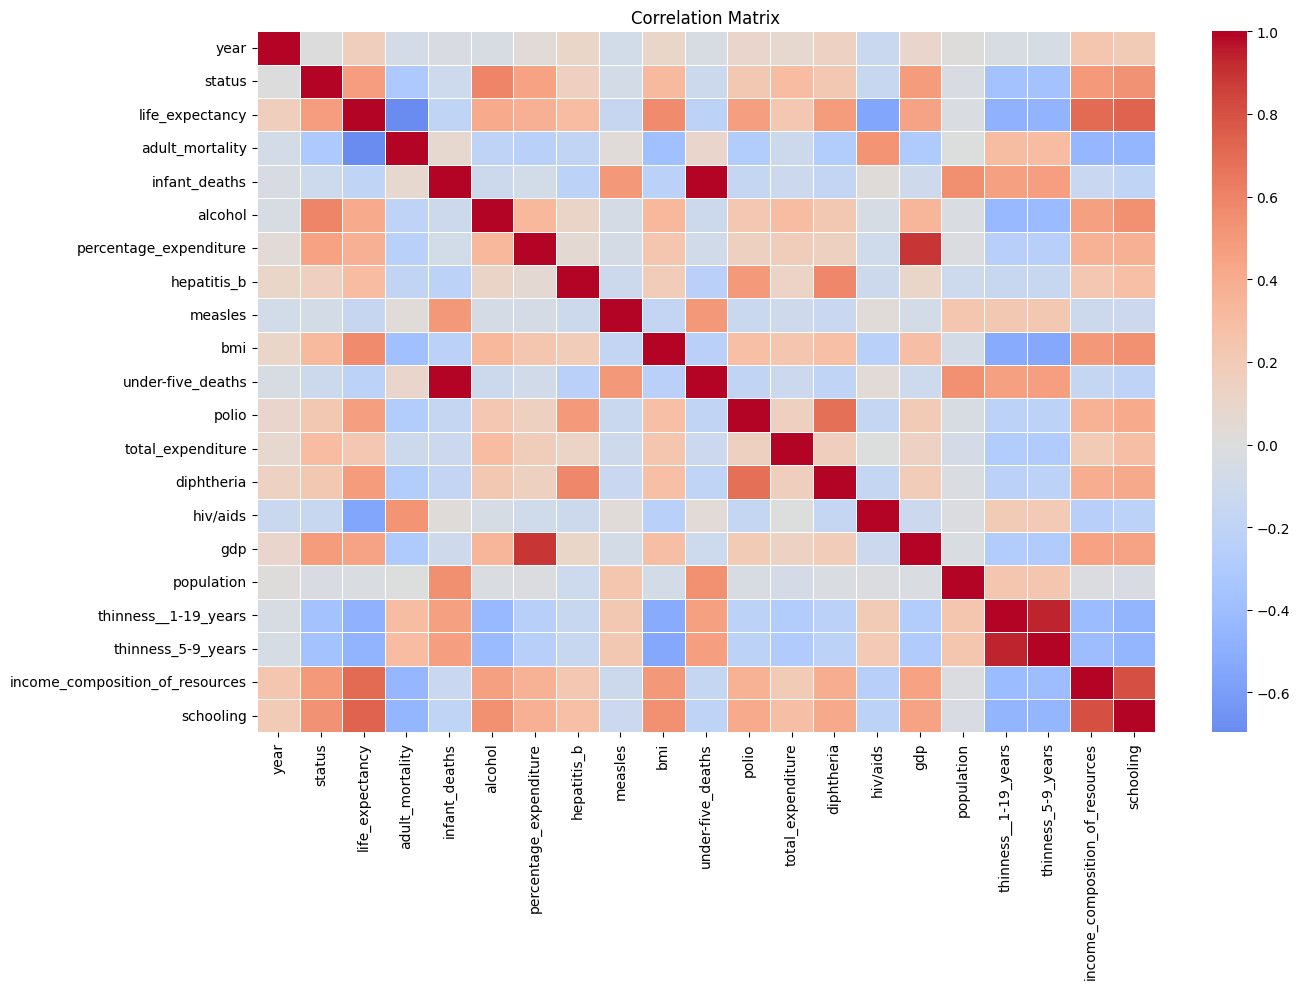

In [3]:
# Correlation heatmap
numeric_df = df.select_dtypes(include = [np.number])

# Compute correlation matrix
corr = numeric_df.corr()

# Plot
plt.figure(figsize = (14, 10))
sns.heatmap(corr, annot = False, cmap = 'coolwarm', center = 0, linewidths = 0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [4]:
# Check the most effective features
life_corr = corr['life_expectancy'].drop('life_expectancy').sort_values(key = abs, ascending = False)
print(life_corr)

schooling                          0.735217
income_composition_of_resources    0.703099
adult_mortality                   -0.696359
bmi                                0.564304
hiv/aids                          -0.556556
diphtheria                         0.485097
status                             0.482136
thinness__1-19_years              -0.472177
polio                              0.471586
thinness_5-9_years                -0.466401
gdp                                0.448414
alcohol                            0.407276
percentage_expenditure             0.381864
hepatitis_b                        0.309315
total_expenditure                  0.228707
under-five_deaths                 -0.222529
infant_deaths                     -0.196557
year                               0.170033
measles                           -0.157586
population                        -0.028982
Name: life_expectancy, dtype: float64


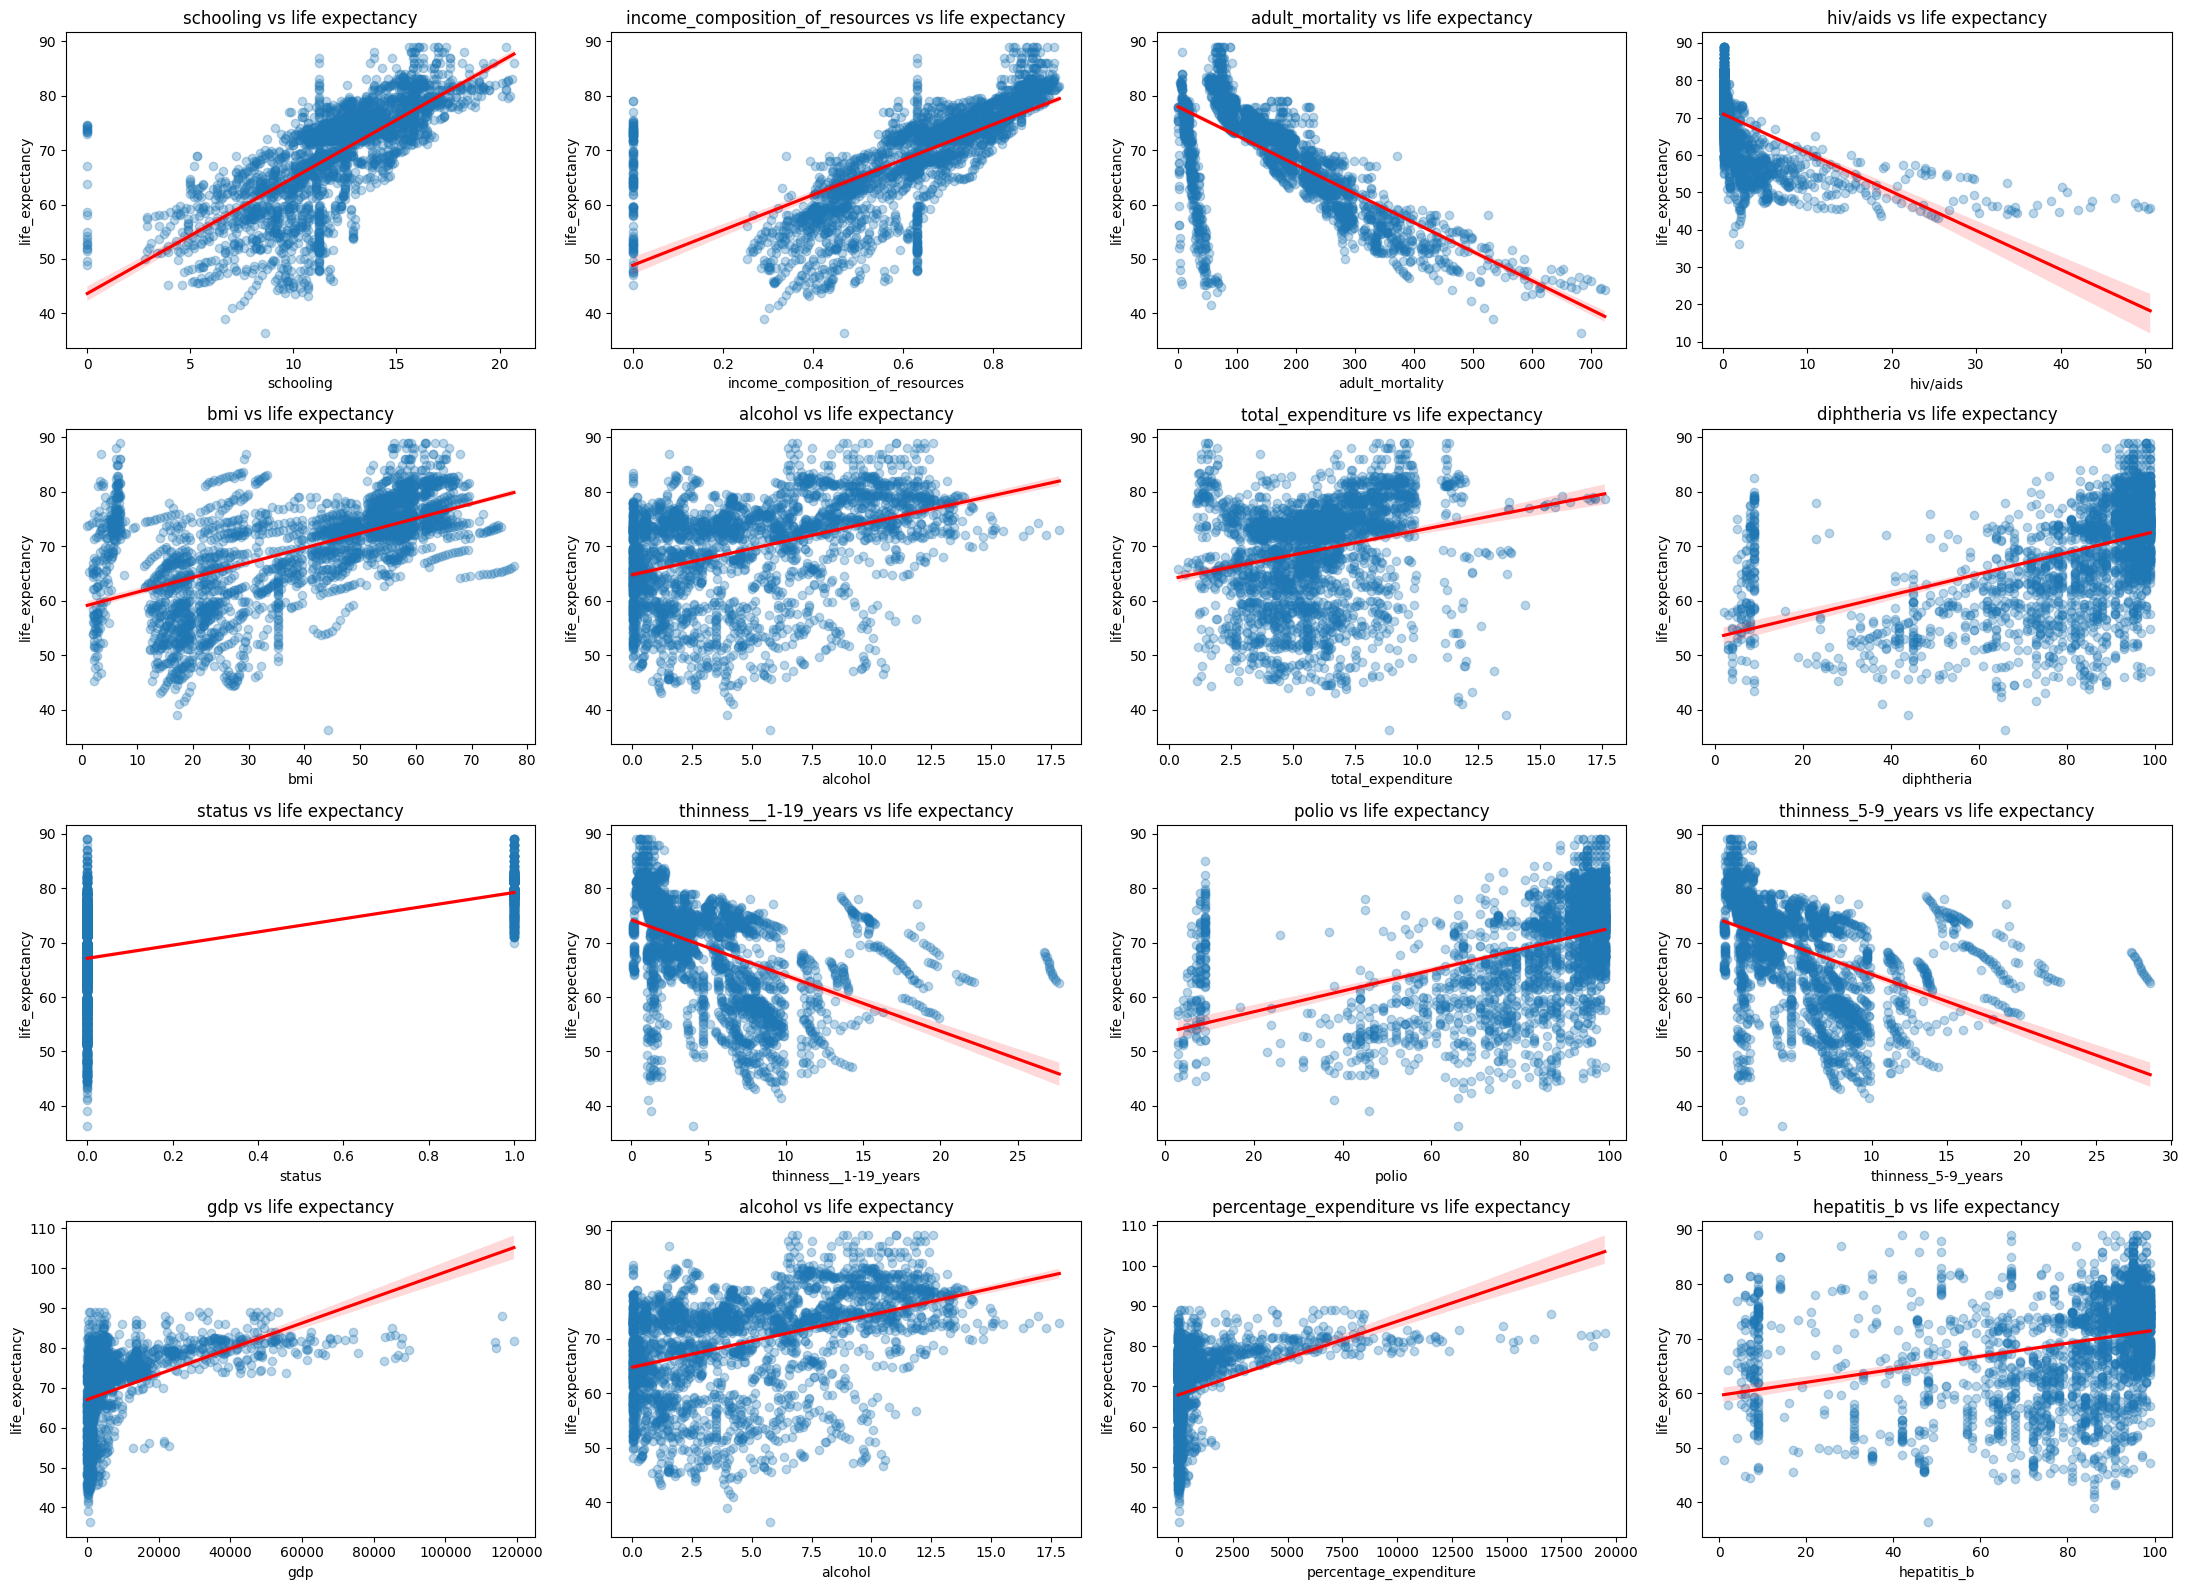

In [5]:
# Scatter plots of top features above 0.3 corr
top_features = ['schooling', 'income_composition_of_resources', 'adult_mortality',
                'hiv/aids', 'bmi', 'alcohol', 'total_expenditure', 'diphtheria',
                'status', 'thinness__1-19_years', 'polio', 'thinness_5-9_years',
                'gdp', 'alcohol', 'percentage_expenditure', 'hepatitis_b']

fig, axes = plt.subplots(4, 4, figsize = (22, 16))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    if i >= len(axes):
        break
    sns.regplot(data = df, x = feat, y = 'life_expectancy', ax = axes[i],
                scatter_kws = {'alpha': 0.3}, line_kws = {'color': 'red'})
    axes[i].set_title(f'{feat} vs life expectancy')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


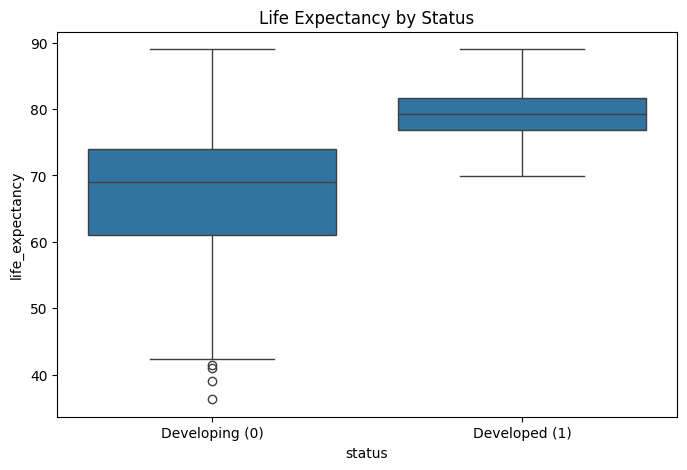

In [6]:
# Status vs. Life expectancy
plt.figure(figsize = (8, 5))
sns.boxplot(data = df, x = 'status', y = 'life_expectancy')
plt.xticks([0, 1], ['Developing (0)', 'Developed (1)'])
plt.title('Life Expectancy by Status')
plt.show()

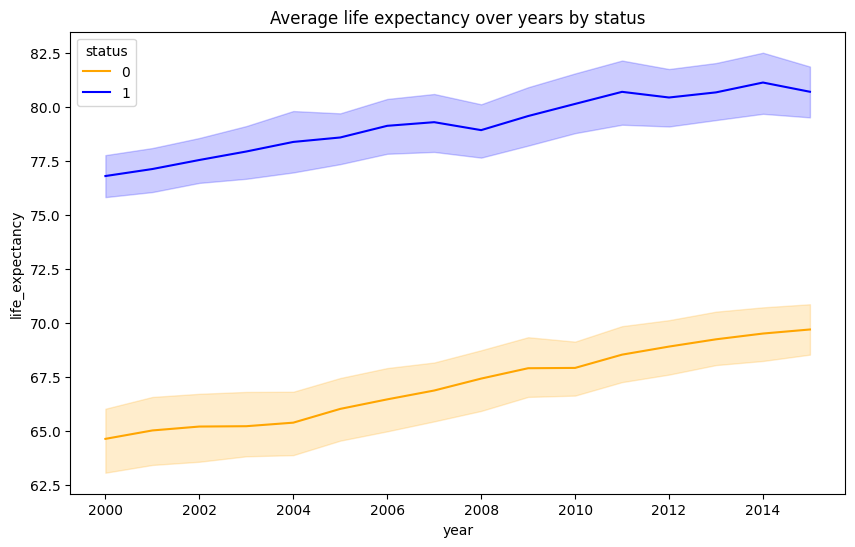

In [7]:
# Life Expectancy trends
plt.figure(figsize = (10, 6))
sns.lineplot(
    data = df,
    x = 'year',
    y = 'life_expectancy',
    hue = 'status',
    palette = ['orange', 'blue'],
)
plt.title('Average life expectancy over years by status')
plt.show()

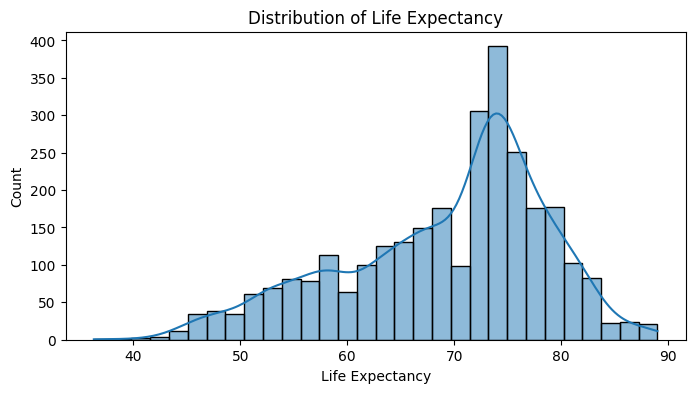

In [8]:
# Distribution of Life expectancy
plt.figure(figsize = (8, 4))
sns.histplot(df['life_expectancy'],
             kde = True,
             bins = 30)
plt.title('Distribution of Life Expectancy')
plt.xlabel('Life Expectancy')
plt.show()

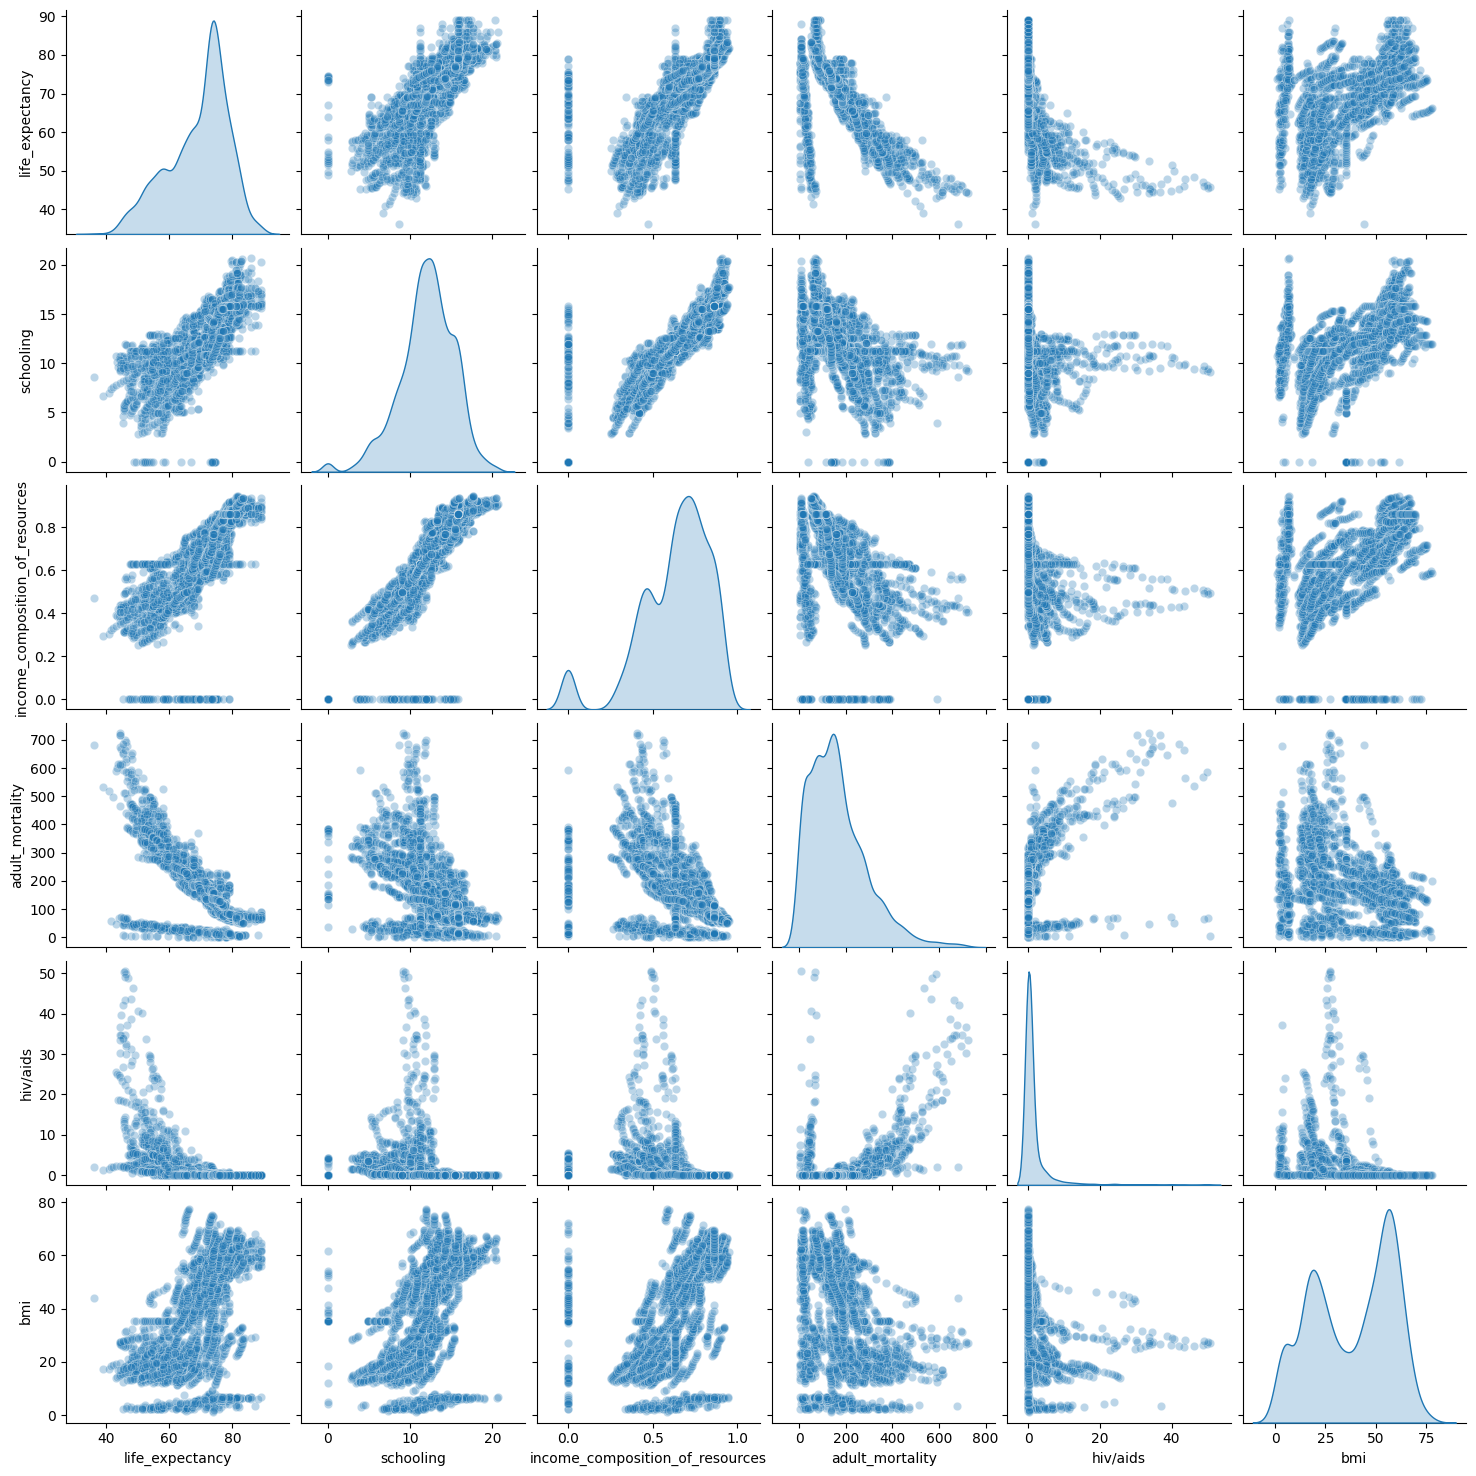

In [9]:
# Pairplot for key values
key_vars = ['life_expectancy', 'schooling', 'income_composition_of_resources',
            'adult_mortality', 'hiv/aids', 'bmi']

sns.pairplot(
    df[key_vars],
    diag_kind = 'kde',
    plot_kws = {'alpha': 0.3}
)
plt.show()